##Importing Libraries

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch.nn as nn
from collections import Counter

##Load the Data from Drive

In [ ]:
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Project 3/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"

# Load the dataset from Google Drive
df = pd.read_csv(file_path)

Mounted at /content/drive


##Task 0: Preprocessing — Map Star Ratings to Sentiment Classes

###1.Data Exploring

In [ ]:
# Show original shape and columns
print("Original shape:\n", df.shape)
print(df.columns)
print("--------------------------------------------------")

Original shape:
 (28332, 24)
Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')
--------------------------------------------------


###2.Data Cleaning

In [ ]:
# Rename 'reviews.text' to 'text'
df = df.rename(columns={'reviews.text': 'text'})

# Drop rows with missing values in important columns
df = df.dropna(subset=['text', 'reviews.rating', 'categories', 'name', 'asins', 'brand', 'id'])

# Clean text
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^A-Za-z0-9.,!?;:'\"()\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text'] = df['text'].apply(clean_text)
df = df[df['text'].str.split().str.len() >= 5]

###3. Mapping

In [ ]:
# Map ratings to sentiment
def map_sentiment(star):
    if star <= 2.0:
        return "Negative"
    elif star == 3.0:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['reviews.rating'].apply(map_sentiment)
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df['label'] = df['sentiment'].map(label_map)

<ipython-input-6-8ff56c6941e0>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['reviews.rating'].apply(map_sentiment)
<ipython-input-6-8ff56c6941e0>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['sentiment'].map(label_map)


###4. Oversampling

In [ ]:
# Oversample to balance classes
df_pos = df[df['label'] == 2]
df_neu = df[df['label'] == 1]
df_neg = df[df['label'] == 0]

df_neu_upsampled = resample(df_neu, replace=True, n_samples=len(df_pos), random_state=42)
df_neg_upsampled = resample(df_neg, replace=True, n_samples=len(df_pos), random_state=42)

df_balanced = pd.concat([df_pos, df_neu_upsampled, df_neg_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Final check
print("Balanced class distribution:\n", df_balanced['label'].value_counts())

Balanced class distribution:
 label
0    22340
1    22340
2    22340
Name: count, dtype: int64


###5. Check for Duplecate Data and process them

In [ ]:
# Count exact duplicate reviews
print("Exact duplicate reviews (text):", df.duplicated(subset='text').sum())
print("Duplicate text+rating pairs:", df.duplicated(subset=['text', 'label']).sum())

df = df.drop_duplicates(subset=['text', 'label'])

# Count exact duplicate reviews
print("\nExact duplicate reviews (text):", df.duplicated(subset='text').sum())
print("Duplicate text+rating pairs:", df.duplicated(subset=['text', 'label']).sum())


Exact duplicate reviews (text): 8501
Duplicate text+rating pairs: 8499

Exact duplicate reviews (text): 2
Duplicate text+rating pairs: 0


In [ ]:
df = df_balanced.copy()

###6. Check if the Dataset is Balanced

sentiment
Negative    22340
Neutral     22340
Positive    22340
Name: count, dtype: int64


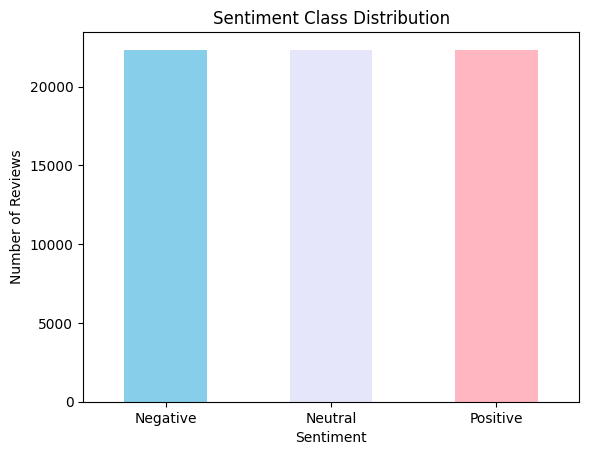

In [ ]:
import matplotlib.pyplot as plt

# Print sentiment counts
print(df['sentiment'].value_counts())

# Plot the sentiment class distribution
df['sentiment'].value_counts().plot(kind='bar', color=['#87CEEB', '#E6E6FA', '#FFB6C1'])

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


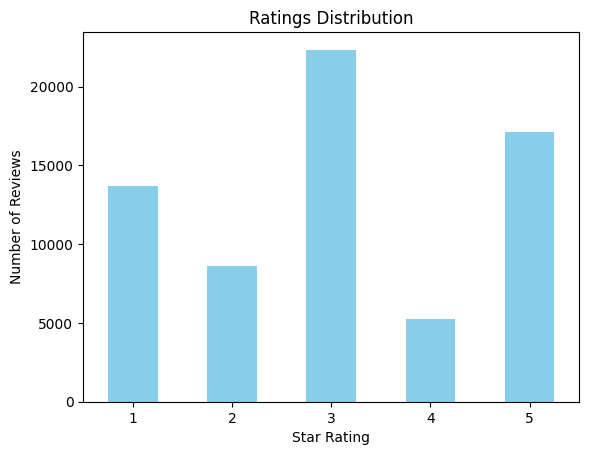

In [ ]:
import matplotlib.pyplot as plt

# Ratings distribution (1–5 stars) as bar chart using pandas
df['reviews.rating'].value_counts().sort_index().plot(kind='bar', color='skyblue')

plt.title("Ratings Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


##Convert Cleaned DataFrame to Hugging Face Format

###1. Prepare the dataset

In [ ]:
# Keep only text and label columns
df_hf = df_balanced[['text', 'label']].copy()

# Convert to Hugging Face Dataset format
dataset = Dataset.from_pandas(df_hf)

# Split into training and validation sets
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = dataset_split['train']
val_dataset = dataset_split['test']

###2.Load tokenizer and model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load tokenizer and model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###3. Tokenize the datasets

In [ ]:
# Tokenize the text data
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/53616 [00:00<?, ? examples/s]

Map:   0%|          | 0/13404 [00:00<?, ? examples/s]

###4.Format datasets for PyTorch

In [ ]:
# Convert datasets to PyTorch tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Preview a sample
print(train_dataset[0])

{'label': tensor(2), 'input_ids': tensor([ 101, 8278, 3475, 2102, 2004, 5310, 5379, 2004, 2060, 9639, 2021, 1057,
        2131, 2109, 2000, 2009, 1012,  102,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        0,

##Task 1: Classification with pre-trained models.

###1. Model distilbert-base-uncased

####1.1 Tokenization & Dataset Prep

In [ ]:
#Split Data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # to keep class balance
)

# Compute class weights based on the training set
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

#Load Tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize with max length padding
train_encodings = tokenizer(train_texts, truncation=True, padding="max_length", max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding="max_length", max_length=128)

#PyTorch Dataset Class
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        } | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

#Wrap in Dataset objects
train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

Class weights: tensor([1., 1., 1.])


####1.2 Fine-Tuning DistilBERT

In [ ]:
# Load pre-trained model
model_name = "distilbert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Custom Trainer class that uses precomputed class_weights
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(model.device))  # ← This uses the earlier one
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


# Training arguments
training_args = TrainingArguments(
    output_dir="./results-distilbert",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=1
)

# Metric calculation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


####1.3 Model Training

In [ ]:
# Create the Trainer
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: deemat9901 (deemat9901-github) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.205400,0.045838,0.989555,0.989529,0.989720,0.989555
2,0.030400,0.022186,0.995897,0.995893,0.995921,0.995897
3,0.008500,0.018689,0.996568,0.996565,0.996584,0.996568


TrainOutput(global_step=10053, training_loss=0.08144954092097285, metrics={'train_runtime': 539.1528, 'train_samples_per_second': 298.335, 'train_steps_per_second': 18.646, 'total_flos': 5326874030297088.0, 'train_loss': 0.08144954092097285, 'epoch': 3.0})

####1.4 Predict on Validation Set

In [ ]:
preds_output = trainer.predict(val_dataset)
preds = preds_output.predictions.argmax(axis=1)

print(preds[:200])  # Just to see the first 200 predicted labels

[0 1 2 2 2 2 0 2 1 1 2 1 1 1 2 2 0 1 2 1 1 0 1 0 1 0 0 0 2 2 1 0 0 1 0 0 2
 0 0 2 0 2 0 1 1 0 1 2 1 1 0 2 1 1 2 1 0 0 0 2 0 1 1 1 1 1 2 2 1 2 0 0 1 0
 2 1 1 2 1 0 1 2 2 0 1 0 0 1 2 2 0 2 2 1 0 2 2 1 2 1 2 2 1 1 1 1 0 0 2 2 1
 0 1 1 0 0 1 0 0 1 0 2 2 2 0 0 0 1 0 1 0 0 0 2 0 1 2 1 2 1 2 2 1 2 2 2 0 1
 2 0 0 0 0 0 0 1 2 1 1 2 2 0 2 1 2 2 1 2 2 0 2 1 0 1 0 0 1 2 1 2 0 2 2 1 0
 1 1 0 2 2 0 2 2 1 0 0 1 1 1 2]


####1.5 Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, preds, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.99      1.00      1.00      4468
     Neutral       1.00      1.00      1.00      4468
    Positive       1.00      0.99      1.00      4468

    accuracy                           1.00     13404
   macro avg       1.00      1.00      1.00     13404
weighted avg       1.00      1.00      1.00     13404



####1.6 Confusion Matrix

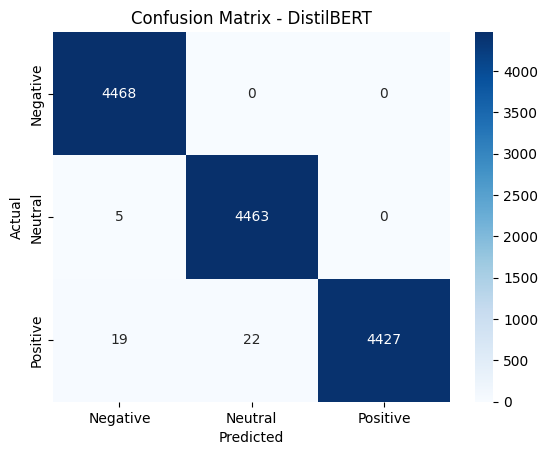

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

####1.7 Save Model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M1_distilbert")
tokenizer.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M1_distilbert")

('/content/drive/MyDrive/Ironhack/Project3/M1_distilbert/tokenizer_config.json',
 '/content/drive/MyDrive/Ironhack/Project3/M1_distilbert/special_tokens_map.json',
 '/content/drive/MyDrive/Ironhack/Project3/M1_distilbert/vocab.txt',
 '/content/drive/MyDrive/Ironhack/Project3/M1_distilbert/added_tokens.json',
 '/content/drive/MyDrive/Ironhack/Project3/M1_distilbert/tokenizer.json')

###2. Model bert-base-uncased

####2.1 Tokenization & Dataset Prep

In [ ]:
# Split data
train_texts_bert, val_texts_bert, train_labels_bert, val_labels_bert = train_test_split(
    df_balanced['text'].tolist(),
    df_balanced['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

# Compute class weights
class_weights_bert = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_bert),
    y=train_labels_bert
)
class_weights_bert = torch.tensor(class_weights_bert, dtype=torch.float)
print("Class weights:", class_weights_bert)

# Tokenizer
bert_model_name = "bert-base-uncased"
tokenizer_bert = AutoTokenizer.from_pretrained(bert_model_name)

# Tokenize
train_encodings_bert = tokenizer_bert(train_texts_bert, truncation=True, padding="max_length", max_length=128)
val_encodings_bert = tokenizer_bert(val_texts_bert, truncation=True, padding="max_length", max_length=128)

# Dataset class
class BertReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            key: torch.tensor(val[idx]) for key, val in self.encodings.items()
        } | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

# Wrap
train_dataset_bert = BertReviewDataset(train_encodings_bert, train_labels_bert)
val_dataset_bert = BertReviewDataset(val_encodings_bert, val_labels_bert)


Class weights: tensor([1., 1., 1.])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

####2.2 Fine-Tuning

In [ ]:
# Load model
model_bert = AutoModelForSequenceClassification.from_pretrained(bert_model_name, num_labels=3)

# Custom Trainer
class WeightedLossTrainerBert(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_bert.to(model.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Training arguments
training_args_bert = TrainingArguments(
    output_dir="./results-bert",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=1
)

# Metrics

def compute_metrics_bert(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


####2.3 Model Training

In [ ]:
# 1.3 Model Training
trainer_bert = WeightedLossTrainerBert(
    model=model_bert,
    args=training_args_bert,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics_bert
)

trainer_bert.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.186800,0.054604,0.987989,0.987971,0.988267,0.987989
2,0.025000,0.012978,0.997314,0.997313,0.997323,0.997314
3,0.007100,0.020569,0.996941,0.996940,0.996954,0.996941


TrainOutput(global_step=10053, training_loss=0.0729524416436393, metrics={'train_runtime': 956.9517, 'train_samples_per_second': 168.084, 'train_steps_per_second': 10.505, 'total_flos': 1.0580316753678336e+16, 'train_loss': 0.0729524416436393, 'epoch': 3.0})

#### 2.4 Predict on Validation Set

In [ ]:
preds_output_bert = trainer_bert.predict(val_dataset_bert)
preds_bert = preds_output_bert.predictions.argmax(axis=1)
print(preds_bert[:200])

[0 1 2 2 2 2 0 2 1 1 2 1 1 1 2 2 0 1 2 1 1 0 1 0 1 0 0 0 2 2 1 0 0 1 0 0 2
 0 0 2 0 2 0 2 1 0 1 2 1 1 0 2 1 1 2 1 0 0 0 2 0 1 1 1 1 1 2 2 1 2 0 0 1 0
 2 1 1 2 1 0 1 2 2 0 1 0 0 1 2 2 0 2 2 1 0 2 2 1 2 1 2 2 1 1 1 1 0 0 2 2 1
 0 1 1 0 0 1 0 0 1 0 2 2 2 0 0 0 1 0 1 0 0 0 2 0 1 1 1 2 1 2 2 1 2 2 2 0 1
 2 0 0 0 0 0 0 1 2 1 1 2 2 0 2 1 2 2 1 2 2 0 2 1 0 1 0 0 1 2 1 2 0 2 2 1 0
 1 1 0 2 2 0 2 2 1 0 0 1 1 1 2]


####2.5 Classification Report

In [ ]:
print(classification_report(val_labels_bert, preds_bert, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4468
     Neutral       1.00      1.00      1.00      4468
    Positive       1.00      0.99      1.00      4468

    accuracy                           1.00     13404
   macro avg       1.00      1.00      1.00     13404
weighted avg       1.00      1.00      1.00     13404



#### 2.6 Confusion Matrix

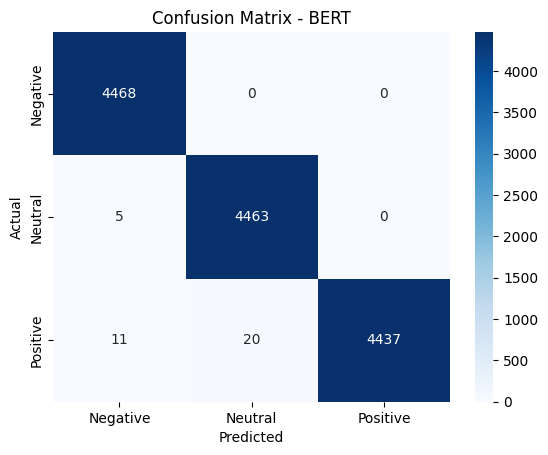

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_bert = confusion_matrix(val_labels_bert, preds_bert)
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT")
plt.show()

#### 2.7 Save Model

In [ ]:
model_bert.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M2_bert")
tokenizer_bert.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M2_bert")

('/content/drive/MyDrive/Ironhack/Project3/M2_bert/tokenizer_config.json',
 '/content/drive/MyDrive/Ironhack/Project3/M2_bert/special_tokens_map.json',
 '/content/drive/MyDrive/Ironhack/Project3/M2_bert/vocab.txt',
 '/content/drive/MyDrive/Ironhack/Project3/M2_bert/added_tokens.json',
 '/content/drive/MyDrive/Ironhack/Project3/M2_bert/tokenizer.json')

###3. Model roberta-base

#### 3.1 Tokenization & Dataset Prep

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer
import torch
import numpy as np

# Split data
train_texts_roberta, val_texts_roberta, train_labels_roberta, val_labels_roberta = train_test_split(
    df_balanced['text'].tolist(),
    df_balanced['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

# Compute class weights
class_weights_roberta = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_roberta),
    y=train_labels_roberta
)
class_weights_roberta = torch.tensor(class_weights_roberta, dtype=torch.float)
print("Class weights:", class_weights_roberta)

# Tokenizer
roberta_model_name = "roberta-base"
tokenizer_roberta = AutoTokenizer.from_pretrained(roberta_model_name)

# Tokenize
train_encodings_roberta = tokenizer_roberta(train_texts_roberta, truncation=True, padding="max_length", max_length=128)
val_encodings_roberta = tokenizer_roberta(val_texts_roberta, truncation=True, padding="max_length", max_length=128)

# Dataset class
class RobertaReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            key: torch.tensor(val[idx]) for key, val in self.encodings.items()
        } | {'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

# Wrap
train_dataset_roberta = RobertaReviewDataset(train_encodings_roberta, train_labels_roberta)
val_dataset_roberta = RobertaReviewDataset(val_encodings_roberta, val_labels_roberta)

Class weights: tensor([1., 1., 1.])


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

#### 3.2 Fine-Tuning RoBERTa

In [ ]:

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load model
model_roberta = AutoModelForSequenceClassification.from_pretrained(roberta_model_name, num_labels=3)

# Custom Trainer
class WeightedLossTrainerRoberta(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=class_weights_roberta.to(model.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Training arguments
training_args_roberta = TrainingArguments(
    output_dir="./results-roberta",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=1
)

# Metrics

def compute_metrics_roberta(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


#### 3.3 Model Training

In [ ]:
trainer_roberta = WeightedLossTrainerRoberta(
    model=model_roberta,
    args=training_args_roberta,
    train_dataset=train_dataset_roberta,
    eval_dataset=val_dataset_roberta,
    compute_metrics=compute_metrics_roberta
)

trainer_roberta.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.219900,0.064702,0.986646,0.986604,0.986919,0.986646
2,0.046300,0.021427,0.995897,0.995896,0.995919,0.995897
3,0.013800,0.024147,0.996270,0.996266,0.996289,0.996270


TrainOutput(global_step=10053, training_loss=0.09333797133432553, metrics={'train_runtime': 969.3591, 'train_samples_per_second': 165.932, 'train_steps_per_second': 10.371, 'total_flos': 1.0580316753678336e+16, 'train_loss': 0.09333797133432553, 'epoch': 3.0})

#### 3.4 Predict on Validation Set

In [ ]:
preds_output_roberta = trainer_roberta.predict(val_dataset_roberta)
preds_roberta = preds_output_roberta.predictions.argmax(axis=1)
print(preds_roberta[:200])

[0 1 2 2 2 2 0 2 1 1 2 1 1 1 2 2 0 1 2 1 1 0 1 0 1 0 0 0 2 2 1 0 0 1 0 0 2
 0 0 2 0 2 0 2 1 0 1 2 1 1 0 2 1 1 2 1 0 0 0 2 0 1 1 1 1 1 2 2 1 2 0 0 1 0
 2 1 1 2 1 0 1 2 2 0 1 0 0 1 2 2 0 2 2 1 0 2 2 1 2 1 2 2 1 1 1 1 0 0 2 2 1
 0 1 1 0 0 1 0 0 1 0 2 2 2 0 0 0 1 0 1 0 0 0 2 0 1 1 1 2 1 2 2 1 2 2 2 0 1
 2 0 0 0 0 0 0 1 2 1 1 2 2 0 2 1 2 2 1 2 2 0 2 1 0 1 0 0 1 2 1 2 0 2 2 1 0
 1 1 0 2 2 0 2 2 1 0 0 1 1 1 2]


#### 3.5 Classification Report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(val_labels_roberta, preds_roberta, target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      4468
     Neutral       0.99      1.00      1.00      4468
    Positive       1.00      0.99      1.00      4468

    accuracy                           1.00     13404
   macro avg       1.00      1.00      1.00     13404
weighted avg       1.00      1.00      1.00     13404



#### 3.6 Confusion Matrix

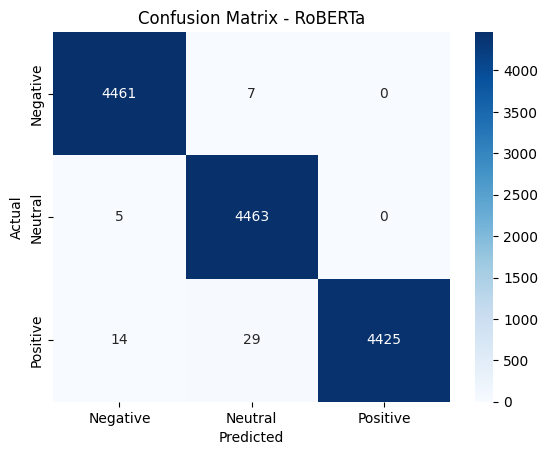

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_roberta = confusion_matrix(val_labels_roberta, preds_roberta)
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RoBERTa")
plt.show()

#### 3.7 Save Model

In [ ]:

model_roberta.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M3_roberta")
tokenizer_roberta.save_pretrained("/content/drive/MyDrive/Ironhack/Project3/M3_roberta")


('/content/drive/MyDrive/Ironhack/Project3/M3_roberta/tokenizer_config.json',
 '/content/drive/MyDrive/Ironhack/Project3/M3_roberta/special_tokens_map.json',
 '/content/drive/MyDrive/Ironhack/Project3/M3_roberta/vocab.json',
 '/content/drive/MyDrive/Ironhack/Project3/M3_roberta/merges.txt',
 '/content/drive/MyDrive/Ironhack/Project3/M3_roberta/added_tokens.json',
 '/content/drive/MyDrive/Ironhack/Project3/M3_roberta/tokenizer.json')

###4. Results Comparing

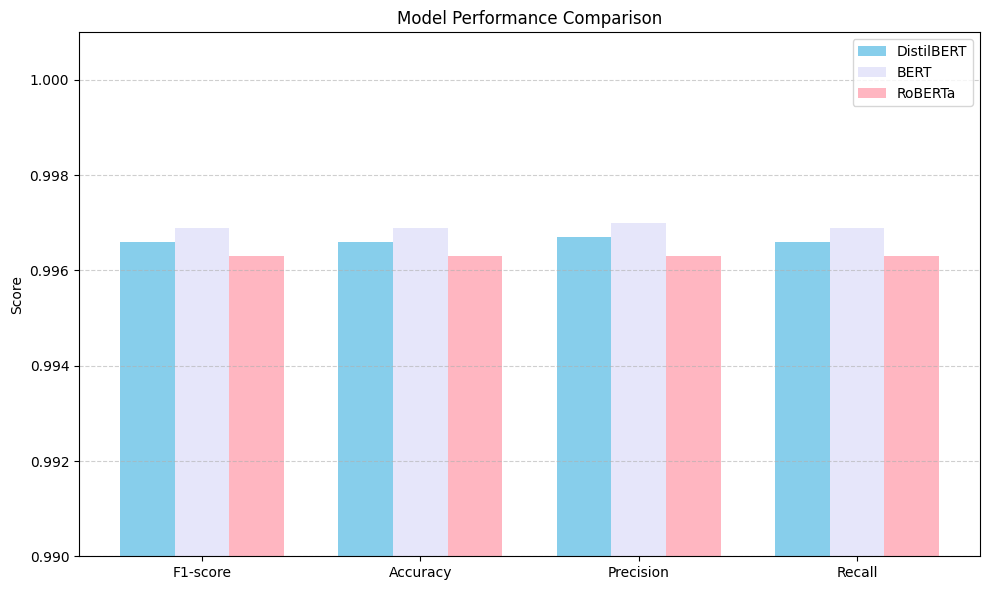

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance values (F1-score, Accuracy, Precision, Recall)
metrics = ['F1-score', 'Accuracy', 'Precision', 'Recall']
distilbert = [0.9966, 0.9966, 0.9967, 0.9966]
bert = [0.9969, 0.9969, 0.9970, 0.9969]
roberta = [0.9963, 0.9963, 0.9963, 0.9963]

# Set up bar plot
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, distilbert, width, label='DistilBERT', color='#87CEEB')  # Sky blue
bars2 = ax.bar(x, bert, width, label='BERT', color='#E6E6FA')  # Lavender
bars3 = ax.bar(x + width, roberta, width, label='RoBERTa', color='#FFB6C1')  # Baby pink

# Labels and formatting
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.99, 1.001)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


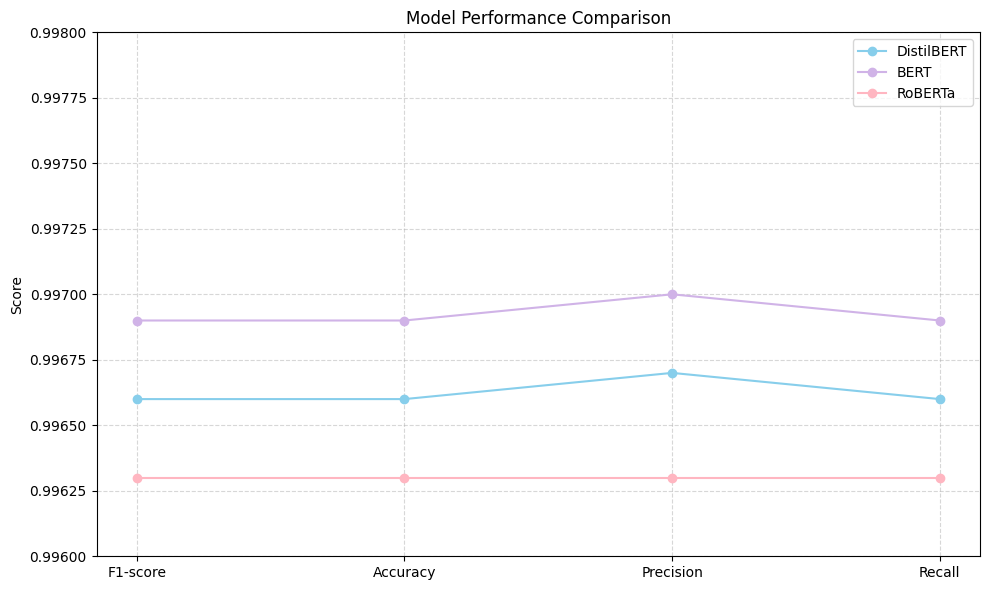

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(metrics, distilbert, marker='o', label='DistilBERT', color='#87CEEB')  # Sky blue
plt.plot(metrics, bert, marker='o', label='BERT', color='#d0b3e7')              # Lavender
plt.plot(metrics, roberta, marker='o', label='RoBERTa', color='#FFB6C1')        # Baby pink

plt.title("Model Performance Comparison")
plt.ylim(0.996, 0.998)
plt.ylabel("Score")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


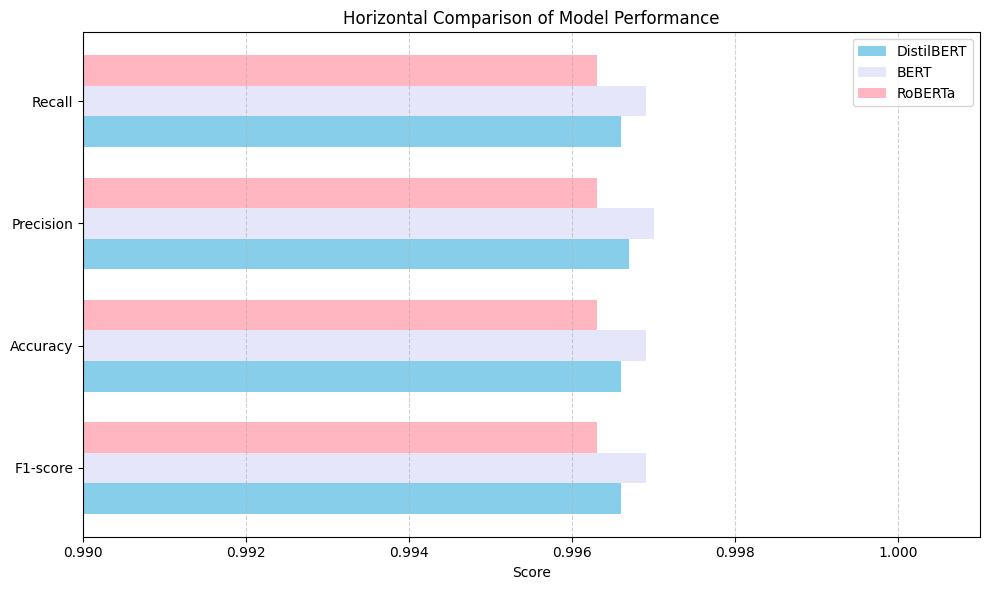

In [ ]:
bar_width = 0.25
x = np.arange(len(metrics))

plt.figure(figsize=(10, 6))
plt.barh(x - bar_width, distilbert[:4], height=bar_width, label='DistilBERT', color='#87CEEB')
plt.barh(x, bert[:4], height=bar_width, label='BERT', color='#E6E6FA')
plt.barh(x + bar_width, roberta[:4], height=bar_width, label='RoBERTa', color='#FFB6C1')

plt.xlabel("Score")
plt.yticks(x, metrics)
plt.title("Horizontal Comparison of Model Performance")
plt.xlim(0.99, 1.001)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


##Task 2. Product Category Clustering


###2.1 Extract product category


In [ ]:
df_balanced['main_category'] = df_balanced['categories'].apply(lambda x: str(x).split(',')[0].strip())

print(f"Total unique categories: {df_balanced['main_category'].nunique()}")
print(df_balanced['main_category'].value_counts().head())

Total unique categories: 26
main_category
AA               31718
Fire Tablets     27424
Computers         3549
Amazon Echo       1459
eBook Readers     1329
Name: count, dtype: int64


###2.2 Sentence-BERT Model

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

####2.2.1 Generate embeddings from product names using Sentence-BERT

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load sentence transformer
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Drop duplicates and missing names
df_names = df_balanced[['name']].dropna().drop_duplicates().reset_index(drop=True)
print(f"Unique product names: {len(df_names)}")

# Create embeddings for each name
name_embeddings = model_sbert.encode(df_names['name'].tolist(), show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Unique product names: 65


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

####2.2.2 Apply K-Means clustering

In [ ]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
name_clusters = kmeans.fit_predict(name_embeddings)

# Add to DataFrame
df_names['name_cluster'] = name_clusters

####2.2.3 Merge cluster labels into original dataset

In [ ]:
# Merge the cluster label back to df_balanced based on product name
df_balanced = df_balanced.merge(df_names, on='name', how='left')

# Preview
df_balanced[['name', 'name_cluster', 'primaryCategories']].sample(10)

,name,name_cluster,primaryCategories
60824,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2,Electronics
34656,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",2,Electronics
26133,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",2,Electronics
45512,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",2,Electronics
13526,AmazonBasics AAA Performance Alkaline Batterie...,1,Health & Beauty
43781,"Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...",2,"Office Supplies,Electronics"
5539,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",0,Electronics
18494,AmazonBasics AAA Performance Alkaline Batterie...,1,Health & Beauty
3916,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2,Electronics
50189,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",2,Electronics


####2.2.4 Visualize how name clusters align with primaryCategories

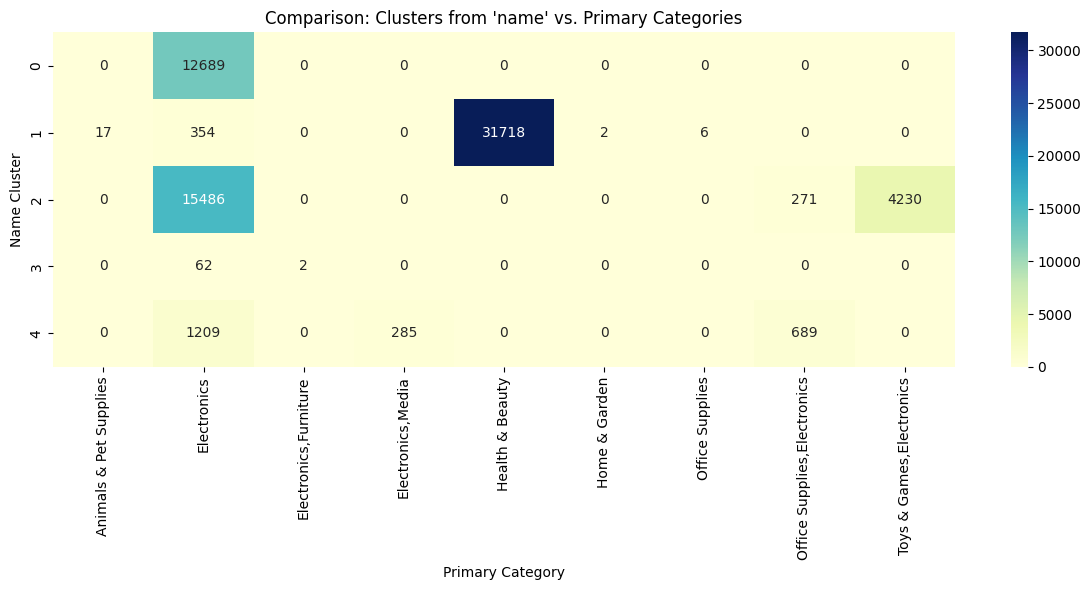

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab comparison
cross_tab = pd.crosstab(df_balanced['name_cluster'], df_balanced['primaryCategories'])

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cross_tab, cmap='YlGnBu', annot=True, fmt='d')
plt.title("Comparison: Clusters from 'name' vs. Primary Categories")
plt.ylabel("Name Cluster")
plt.xlabel("Primary Category")
plt.tight_layout()
plt.show()

 #### 2.2.5 Analyze Clusters vs Primary Categories

In [ ]:
# Compare name_cluster vs primaryCategories
cross_tab = pd.crosstab(df_balanced['name_cluster'], df_balanced['primaryCategories'])
print(cross_tab)

primaryCategories  Animals & Pet Supplies  Electronics  Electronics,Furniture  \
name_cluster                                                                    
0                                       0        12689                      0   
1                                      17          354                      0   
2                                       0        15486                      0   
3                                       0           62                      2   
4                                       0         1209                      0   

primaryCategories  Electronics,Media  Health & Beauty  Home & Garden  \
name_cluster                                                           
0                                  0                0              0   
1                                  0            31718              2   
2                                  0                0              0   
3                                  0                0              0   


####2.2.6 Mapping

In [ ]:
# Step 1: Manually define your cluster → meta_category map
cluster_map = {
    0: "Electronics",
    1: "Health Products",
    2: "Tablets & Kids Devices",
    3: "Office Accessories",
    4: "Other"
}

# Step 2: Create a new DataFrame from unique names and their clusters
category_cluster_df = df_balanced[['name', 'name_cluster']].drop_duplicates()
category_cluster_df['meta_category'] = category_cluster_df['name_cluster'].map(cluster_map)

# Step 3: Merge the meta category into the main dataset
df_balanced = df_balanced.merge(category_cluster_df[['name', 'meta_category']], on='name', how='left')


####2.2.7 Save the model

In [ ]:
df_balanced.to_csv("/content/drive/MyDrive//Project 3/df_balanced.csv", index=False)


In [ ]:
from sentence_transformers import SentenceTransformer

# Load the model used in Task 2
sentence_bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Save the model
sentence_bert_model.save("/content/drive/MyDrive//Project 3/task2_sentencebert_model")

##Task 3. Summarize reviews using generative AI

###3.1 Prepare Review Texts for Each Product

In [ ]:
# Group reviews by meta_category and product name
product_reviews = df_balanced.groupby(['meta_category', 'name'])['text'].apply(lambda texts: ' '.join(texts)).reset_index()

###3.2 BART model

###3.2.1 Generate Summaries Using BART

In [ ]:
from transformers import BartTokenizer, BartForConditionalGeneration

# Load BART model and tokenizer
bart_model_name = "facebook/bart-large-cnn"
bart_tokenizer = BartTokenizer.from_pretrained(bart_model_name)
bart_model = BartForConditionalGeneration.from_pretrained(bart_model_name)

def generate_summary(text, max_input_length=1024, max_output_length=200):
    inputs = bart_tokenizer(text, return_tensors="pt", truncation=True, max_length=max_input_length)
    summary_ids = bart_model.generate(inputs["input_ids"], max_length=max_output_length, num_beams=4, early_stopping=True)
    return bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

###3.2.2 Generate Articles for Each Meta Category

In [ ]:
# Assuming top_products and worst_products DataFrames are already defined
category_articles = {}

for category in top_products['meta_category'].unique():
    top = top_products[top_products['meta_category'] == category]
    worst = worst_products[worst_products['meta_category'] == category]

    article = f"### Top Products in {category}\n"

    for _, row in top.iterrows():
        product_name = row['name']
        reviews_text = product_reviews[(product_reviews['meta_category'] == category) & (product_reviews['name'] == product_name)]['text'].values
        if reviews_text:
            summary = generate_summary(reviews_text[0])
            article += f"\n**{product_name}**\nSummary: {summary}\n"

    article += f"\n### Product to Avoid in {category}\n"
    worst_row = worst.iloc[0]
    worst_name = worst_row['name']
    reviews_text = product_reviews[(product_reviews['meta_category'] == category) & (product_reviews['name'] == worst_name)]['text'].values
    if reviews_text:
        summary = generate_summary(reviews_text[0])
        article += f"\n**{worst_name}**\nIssues: {summary}\n"

    category_articles[category] = article


###3.2.3 Generate Articles for Each Meta Category

In [ ]:
# Assuming top_products and worst_products DataFrames are already defined
category_articles = {}

for category in top_products['meta_category'].unique():
    top = top_products[top_products['meta_category'] == category]
    worst = worst_products[worst_products['meta_category'] == category]

    article = f"Top Products in {category}\n"

    for _, row in top.iterrows():
        product_name = row['name']
        reviews_text = product_reviews[(product_reviews['meta_category'] == category) & (product_reviews['name'] == product_name)]['text'].values
        if reviews_text:
            summary = generate_summary(reviews_text[0])
            article += f"\nProduct name: {product_name}\nSummary: {summary}\n"

    article += f"\nProduct to Avoid in {category}\n"
    worst_row = worst.iloc[0]
    worst_name = worst_row['name']
    reviews_text = product_reviews[(product_reviews['meta_category'] == category) & (product_reviews['name'] == worst_name)]['text'].values
    if reviews_text:
        summary = generate_summary(reviews_text[0])
        article += f"\n{worst_name}\nIssues: {summary}\n"

    category_articles[category] = article

In [ ]:
# Example: Print article for a specific category
print(category_articles['Electronics'])

Top Products in Electronics

Product name: Fire TV Stick Streaming Media Player Pair Kit
Summary: This device allows you to cut your cable. You can use apps like Kodi and TubiTV to watch many shows. Yes, there are commercials but not as many as other services. The mirror cast function didn't seem to work well displaying video while it was steaming to a Windows 10 laptop. Buy this, check it out, enjoy your freedom from cable TV!

Product name: Amazon Fire TV Gaming Edition Streaming Media Player
Summary: This has great possibilities for the ARMCHAIR POTATO by expanding what is available to view. I would recommend this to anyone. Works excellent love it. Easy to use. The item seems to have a 'ton' of items to view just wish it came with some directions on use. Otherwise product is great.

Product name: Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers
Summary: The Amazon Fire HD8 (2016 model) is a great tablet for the price; however, the Fire OS offers lim

###3.2.4 Save the model

In [ ]:
# Save the BART model and tokenizer to your Google Drive
output_dir = "/content/drive/MyDrive/Project 3/M3_bart_summarizer"

# Save model
bart_model.save_pretrained(output_dir)

# Save tokenizer
bart_tokenizer.save_pretrained(output_dir)

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


('/content/drive/MyDrive/Project 3/M3_bart_summarizer/tokenizer_config.json',
 '/content/drive/MyDrive/Project 3/M3_bart_summarizer/special_tokens_map.json',
 '/content/drive/MyDrive/Project 3/M3_bart_summarizer/vocab.json',
 '/content/drive/MyDrive/Project 3/M3_bart_summarizer/merges.txt',
 '/content/drive/MyDrive/Project 3/M3_bart_summarizer/added_tokens.json')